In [2]:
!pip install -q minigrid
!pip install -q stable-baselines3
!pip install -q gymnasium
!pip install -q imageio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 2.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 6.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 4.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.2 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.2

In [4]:
import gymnasium as gym
import minigrid

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

In [10]:
import gymnasium as gym

from minigrid.wrappers import FlatObsWrapper

ENV_NAME = "MiniGrid-Empty-8x8-v0"

env = gym.make(ENV_NAME)

env = FlatObsWrapper(env)

In [6]:
env = gym.make(ENV_NAME)

env = Monitor(env)

print("Observation Space:")
print(env.observation_space)

print("\nAction Space:")
print(env.action_space)

Observation Space:
Dict('direction': Discrete(4), 'image': Box(0, 255, (7, 7, 3), uint8), 'mission': MissionSpace(<function EmptyEnv._gen_mission at 0x7bdcf9e7bc40>, None))

Action Space:
Discrete(7)


In [7]:
obs, info = env.reset()

for _ in range(5):
    
    action = env.action_space.sample()
    
    obs, reward, terminated, truncated, info = env.step(action)

    print("Action:", action)
    print("Reward:", reward)

    if terminated or truncated:
        obs, info = env.reset()

Action: 3
Reward: 0
Action: 1
Reward: 0
Action: 5
Reward: 0
Action: 5
Reward: 0
Action: 1
Reward: 0


In [11]:
print(env.observation_space)

Box(0, 255, (2835,), uint8)


In [12]:
from stable_baselines3 import PPO

model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99
)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [13]:
TIMESTEPS = 50000

model.learn(
    total_timesteps=TIMESTEPS
)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 243      |
|    ep_rew_mean     | 0.0694   |
| time/              |          |
|    fps             | 464      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 241         |
|    ep_rew_mean          | 0.0719      |
| time/                   |             |
|    fps                  | 415         |
|    iterations           | 2           |
|    time_elapsed         | 9           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.015894452 |
|    clip_fraction        | 0.118       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.93       |
|    explained_variance   | -1.11       |
|    learning_rate        | 0.

In [14]:
model.save(
    "results/models/ppo_baseline"
)

print("Model Saved!")

Model Saved!


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:284: UserWarning: Path 'results/models' does not exist. Will create it.
  warnings.warn(f"Path '{path.parent}' does not exist. Will create it.")


In [15]:
def evaluate_agent(model, env, episodes=50):

    rewards = []

    for episode in range(episodes):

        obs, info = env.reset()

        done = False

        total_reward = 0

        while not done:

            action, _ = model.predict(
                obs,
                deterministic=True
            )

            obs, reward, terminated, truncated, info = env.step(action)

            total_reward += reward

            done = terminated or truncated

        rewards.append(total_reward)

    return rewards

In [16]:
scores = evaluate_agent(
    model,
    env,
    episodes=50
)

print("Average Reward:", np.mean(scores))
print("Max Reward:", np.max(scores))
print("Min Reward:", np.min(scores))

Average Reward: 0.961328125
Max Reward: 0.961328125
Min Reward: 0.961328125


In [17]:
scores = evaluate_agent(
    model,
    env,
    episodes=50
)

print("Average Reward:", np.mean(scores))
print("Max Reward:", np.max(scores))
print("Min Reward:", np.min(scores))

Average Reward: 0.961328125
Max Reward: 0.961328125
Min Reward: 0.961328125


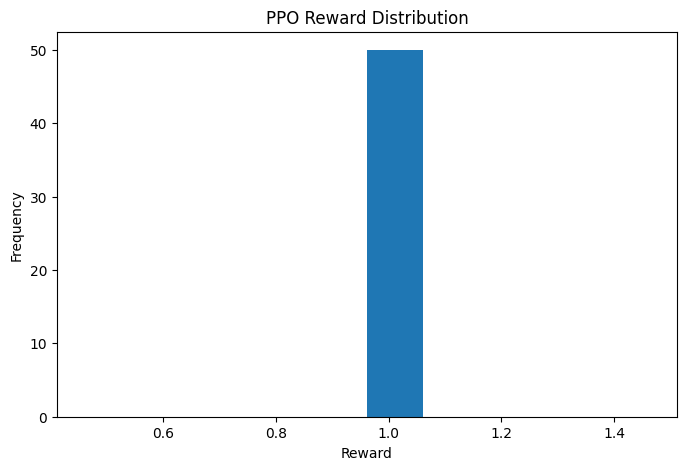

In [18]:
plt.figure(figsize=(8,5))

plt.hist(scores)

plt.title("PPO Reward Distribution")

plt.xlabel("Reward")

plt.ylabel("Frequency")

plt.show()

In [20]:
import os

file_path = "results/tables"

# Create parent directories if they don't exist
os.makedirs(os.path.dirname(file_path), exist_ok=True)

In [22]:
results = pd.DataFrame(
    {
        "reward": scores
    }
)

results.to_csv(
    "results/ppo_results.csv",
    index=False
)

print("Results Saved!")

Results Saved!
